# DIF Detection Under Large n: Analysis Notebook

Monte Carlo simulation over a 60-item Rasch model.  
12 items carry injected DIF (uniform, 3 magnitude tiers); 48 are clean.  
Two detection rules are evaluated across sample sizes n $\in$ [50, 10000]:

- **p-value rule** — flag if Welch t-test p $\leq$ 0.05  
- **contrast rule** — flag if |$\hat{\Delta}$| $\ge$ 0.43 (Winsteps "moderate" threshold)

All summary statistics are expectations over R(n) stratified subsamples.  
Key thresholds derived: **n = 750** (p-value FPR > 10%) and **n = 3,750** (contrast MAE ≤ 0.13 logits).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import plot_style as ps

ps.setup(dpi=150, base_font=11)
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)


In [2]:
MAE_THRESHOLD      = 0.13
FPR_THRESHOLD      = 0.10
CONTRAST_THRESHOLD = 0.43
REFERENCE_MODE     = "true"   # compare estimates against true injected delta
USE_LOG_X          = True
TOTAL_ITEMS        = 60


## 1  Data

In [3]:
base_dir = Path("sample size effects")
item_df        = pd.read_csv(base_dir / "dif_item_level_results.csv")
conv_summary_df = pd.read_csv(base_dir / "dif_effect_convergence_summary.csv")
truth_df       = pd.read_csv("simulated_rasch_dif_truth.csv")

# Attach ground-truth columns (drop any stale copies first)
item_df = item_df.drop(
    columns=[c for c in ["delta_group1", "dif_flag", "dif_type"] if c in item_df.columns],
    errors="ignore",
)
item_df = item_df.merge(
    truth_df[["item_id", "delta_group1", "dif_flag", "dif_type"]],
    on="item_id", how="left",
)

all_n         = sorted(item_df["n_students"].dropna().astype(int).unique())
max_n         = max(all_n)
dif_items     = truth_df.loc[truth_df["dif_flag"],  "item_id"].tolist()
non_dif_items = truth_df.loc[~truth_df["dif_flag"], "item_id"].tolist()

print(f"Loaded {len(item_df):,} observations")
print(f"Sample sizes ({len(all_n)} levels): {all_n}")
print(f"True DIF items : {len(dif_items)}")
print(f"Non-DIF items  : {len(non_dif_items)}")


Loaded 202,560 observations
Sample sizes (35 levels): [np.int64(50), np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(225), np.int64(250), np.int64(275), np.int64(300), np.int64(500), np.int64(750), np.int64(1000), np.int64(1250), np.int64(1500), np.int64(2000), np.int64(2250), np.int64(2500), np.int64(2750), np.int64(3000), np.int64(3250), np.int64(3500), np.int64(3750), np.int64(4000), np.int64(4250), np.int64(4500), np.int64(4750), np.int64(5000), np.int64(5250), np.int64(5500), np.int64(5750), np.int64(7000), np.int64(9000), np.int64(10000)]
True DIF items : 12
Non-DIF items  : 48


## 2  Feature Engineering

In [4]:
item_df["Stat Signif"]     = item_df["Stat Signif"].fillna("")
item_df["Contrast Signif"] = item_df["Contrast Signif"].fillna("")
item_df["dif_type"]        = item_df["dif_type"].fillna("")
item_df["Prob"]            = pd.to_numeric(item_df["Prob"],     errors="coerce")
item_df["contrast"]        = pd.to_numeric(item_df["contrast"], errors="coerce")

# P-value detection flags
item_df["pred_sig_any"]   = item_df["Stat Signif"] != ""
item_df["pred_sig_star"]  = item_df["Stat Signif"] == "*"
item_df["pred_sig_2star"] = item_df["Stat Signif"] == "**"
item_df["pred_sig_3star"] = item_df["Stat Signif"] == "***"

# Contrast detection flags (moderate ≥ 0.43 or large ≥ 0.64)
item_df["pred_contrast_detected"] = item_df["Contrast Signif"].isin(["**", "***"])
item_df["pred_contrast_2star"]    = item_df["Contrast Signif"] == "**"
item_df["pred_contrast_3star"]    = item_df["Contrast Signif"] == "***"
item_df["abs_contrast"]           = item_df["contrast"].abs()

# Anchor at nmax for nmax-relative error
n_max_contrasts = (
    item_df.loc[item_df["n_students"] == max_n]
    .groupby("item_id", as_index=False)
    .agg(contrast_n_max=("contrast", "mean"))
)
item_df = item_df.merge(n_max_contrasts, on="item_id", how="left")

# Absolute errors
item_df["abs_error_to_true"]  = (item_df["contrast"] - item_df["delta_group1"]).abs()
item_df["abs_error_to_nmax"]  = (item_df["contrast"] - item_df["contrast_n_max"]).abs()

item_df["abs_error_true_dif_true_ref"] = np.where(item_df["dif_flag"],  item_df["abs_error_to_true"],   np.nan)
item_df["abs_error_non_dif_true_ref"]  = np.where(~item_df["dif_flag"], item_df["contrast"].abs(),      np.nan)
item_df["abs_error_true_dif_nmax_ref"] = np.where(item_df["dif_flag"],  item_df["abs_error_to_nmax"],   np.nan)
item_df["abs_error_non_dif_nmax_ref"]  = np.where(~item_df["dif_flag"], item_df["abs_error_to_nmax"],   np.nan)

# Intersection rule
item_df["pred_intersection"] = item_df["pred_sig_any"] & item_df["pred_contrast_detected"]


## 3  Aggregate Summaries

All summaries are `E[metric]` over `R(n)` replications at each sample size `n`.

In [5]:
# --- P-value explosion summary ---
p_exp_rep = (
    item_df.groupby(["n_students", "rep"], as_index=False)
    .agg(
        prop_any  =("pred_sig_any",   "mean"),
        prop_star =("pred_sig_star",  "mean"),
        prop_2star=("pred_sig_2star", "mean"),
        prop_3star=("pred_sig_3star", "mean"),
    )
)
p_exp = (
    p_exp_rep.groupby("n_students", as_index=False)
    .agg(
        mean_any   =("prop_any",   "mean"), sd_any   =("prop_any",   "std"),
        mean_star  =("prop_star",  "mean"), sd_star  =("prop_star",  "std"),
        mean_2star =("prop_2star", "mean"), sd_2star =("prop_2star", "std"),
        mean_3star =("prop_3star", "mean"), sd_3star =("prop_3star", "std"),
    )
    .sort_values("n_students")
    .fillna(0.0)
)

# --- Contrast flag summary ---
cf_rep = (
    item_df.groupby(["n_students", "rep"], as_index=False)
    .agg(
        prop_any  =("pred_contrast_detected", "mean"),
        prop_2star=("pred_contrast_2star",    "mean"),
        prop_3star=("pred_contrast_3star",    "mean"),
    )
)
cf = (
    cf_rep.groupby("n_students", as_index=False)
    .agg(
        mean_any  =("prop_any",   "mean"), sd_any  =("prop_any",   "std"),
        mean_2star=("prop_2star", "mean"), sd_2star=("prop_2star", "std"),
        mean_3star=("prop_3star", "mean"), sd_3star=("prop_3star", "std"),
    )
    .sort_values("n_students")
    .fillna(0.0)
)

# --- Contrast MAE convergence ---
true_dif_col = "abs_error_true_dif_true_ref" if REFERENCE_MODE == "true" else "abs_error_true_dif_nmax_ref"
non_dif_col  = "abs_error_non_dif_true_ref"  if REFERENCE_MODE == "true" else "abs_error_non_dif_nmax_ref"

cc_rep = (
    item_df.groupby(["n_students", "rep"], as_index=False)
    .agg(mae_dif=(true_dif_col, "mean"), mae_nodif=(non_dif_col, "mean"))
)
cc = (
    cc_rep.groupby("n_students", as_index=False)
    .agg(
        mean_dif  =("mae_dif",   "mean"), sd_dif  =("mae_dif",   "std"),
        mean_nodif=("mae_nodif", "mean"), sd_nodif=("mae_nodif", "std"),
    )
    .sort_values("n_students")
    .fillna(0.0)
)

# --- Contrast variance ---
cv_item = (
    item_df.groupby(["n_students", "item_id"], as_index=False)
    .agg(var=("contrast", "var"), dif_flag=("dif_flag", "max"))
    .fillna({"var": 0.0})
)
cv = (
    cv_item.groupby(["n_students", "dif_flag"], as_index=False)
    .agg(mean_var=("var", "mean"), sd_var=("var", "std"))
    .sort_values(["dif_flag", "n_students"])
    .fillna({"sd_var": 0.0})
)

print("Summaries built.")


Summaries built.


In [6]:
# --- Classification metrics (p-value, contrast, intersection) ---
def _classification_summary(pred_col: str) -> pd.DataFrame:
    rows = []
    for (n, rep), g in item_df.groupby(["n_students", "rep"]):
        pred  = g[pred_col].astype(bool)
        truth = g["dif_flag"].astype(bool)
        tp = (truth & pred).sum();  fp = (~truth & pred).sum()
        fn = (truth & ~pred).sum(); tn = (~truth & ~pred).sum()
        prec   = tp / (tp + fp)   if (tp + fp)   > 0 else np.nan
        recall = tp / (tp + fn)   if (tp + fn)   > 0 else np.nan
        fpr    = fp / (fp + tn)   if (fp + tn)   > 0 else np.nan
        f1     = 2*prec*recall / (prec+recall) if (pd.notna(prec) and pd.notna(recall) and (prec+recall) > 0) else np.nan
        rows.append({"n_students": int(n), "rep": int(rep),
                     "precision": prec, "recall": recall,
                     "fpr": fpr, "tpr": recall, "f1": f1})
    metrics = pd.DataFrame(rows).sort_values(["n_students", "rep"])
    summary = (
        metrics.groupby("n_students", as_index=False)
        .agg(
            mean_precision=("precision","mean"), sd_precision=("precision","std"),
            mean_recall   =("recall",   "mean"), sd_recall   =("recall",   "std"),
            mean_fpr      =("fpr",      "mean"), sd_fpr      =("fpr",      "std"),
            mean_tpr      =("tpr",      "mean"), sd_tpr      =("tpr",      "std"),
            mean_f1       =("f1",       "mean"), sd_f1       =("f1",       "std"),
        )
        .sort_values("n_students")
        .fillna(0.0)
    )
    return summary

cls_p    = _classification_summary("pred_sig_any")
cls_c    = _classification_summary("pred_contrast_detected")
cls_both = _classification_summary("pred_intersection")

print("Classification summaries built.")


Classification summaries built.


## 4  Derived Thresholds

In [7]:
n_break_p = (
    int(cls_p.loc[cls_p["mean_fpr"] >= FPR_THRESHOLD, "n_students"].iloc[0])
    if not cls_p.loc[cls_p["mean_fpr"] >= FPR_THRESHOLD].empty else None
)
n_trust_c = (
    int(cc.loc[cc["mean_dif"] <= MAE_THRESHOLD, "n_students"].iloc[0])
    if not cc.loc[cc["mean_dif"] <= MAE_THRESHOLD].empty else None
)
peak_f1_p = cls_p.loc[cls_p["mean_f1"].idxmax()]
peak_f1_c = cls_c.loc[cls_c["mean_f1"].idxmax()]

print("Key thresholds")
print(f"  p-value FPR > 10%  :  n = {n_break_p:,}  (FPR = {cls_p.loc[cls_p['n_students']==n_break_p, 'mean_fpr'].values[0]:.1%})")
print(f"  contrast MAE ≤ 0.13:  n = {n_trust_c:,}  (MAE = {cc.loc[cc['n_students']==n_trust_c, 'mean_dif'].values[0]:.4f} logits)")
print(f"  Peak F1 p-value    :  {peak_f1_p['mean_f1']:.3f}  at n = {int(peak_f1_p['n_students']):,}")
print(f"  Peak F1 contrast   :  {peak_f1_c['mean_f1']:.3f}  at n = {int(peak_f1_c['n_students']):,}")
print(f"  Gap (p broken before contrast trusted): {n_trust_c - n_break_p:,} observations")


Key thresholds
  p-value FPR > 10%  :  n = 750  (FPR = 11.6%)
  contrast MAE ≤ 0.13:  n = 3,750  (MAE = 0.1290 logits)
  Peak F1 p-value    :  0.719  at n = 1,250
  Peak F1 contrast   :  0.875  at n = 9,000
  Gap (p broken before contrast trusted): 3,000 observations


## 5  P-value Behaviour

For any fixed non-zero effect the Welch t-statistic grows as O(√n), so the null will be rejected with probability approaching 1 regardless of effect magnitude.  
The plots below show that this holds empirically: at n = 750 the false positive rate on clean items already exceeds 10%, and by n = 10 000 roughly 80% of all items are flagged.


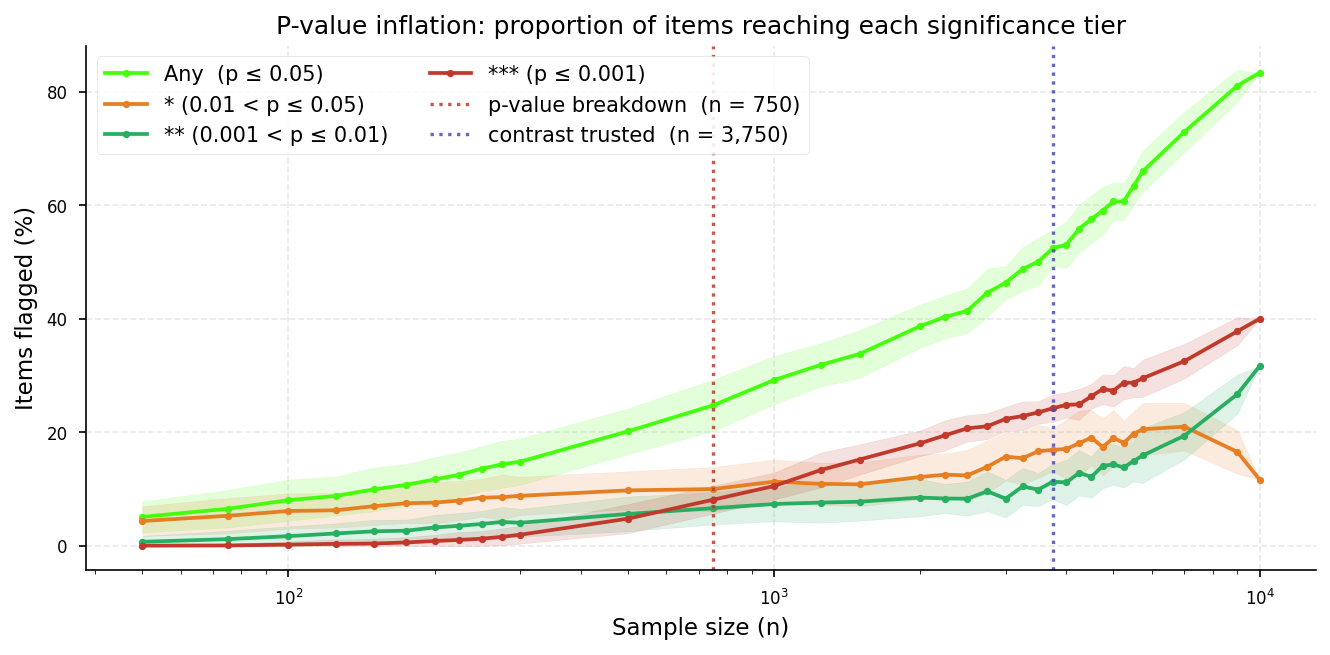

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = p_exp["n_students"]

for col, label, color in [
    ("mean_any",   "Any  (p ≤ 0.05)",  ps.C["pval"]),
    ("mean_star",  "* (0.01 < p ≤ 0.05)", ps.C["star1"]),
    ("mean_2star", "** (0.001 < p ≤ 0.01)", ps.C["star2"]),
    ("mean_3star", "*** (p ≤ 0.001)",   ps.C["star3"]),
]:
    ps.band(ax, x, 100 * p_exp[col], 100 * p_exp[col.replace("mean_","sd_")],
            color=color, label=label)

ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Items flagged (%)")
ax.set_title("P-value inflation: proportion of items reaching each significance tier")
ax.legend(ncols=2, loc="upper left")
plt.tight_layout()
ps.save(fig, figures_dir / "p_explosion.png")
plt.show()


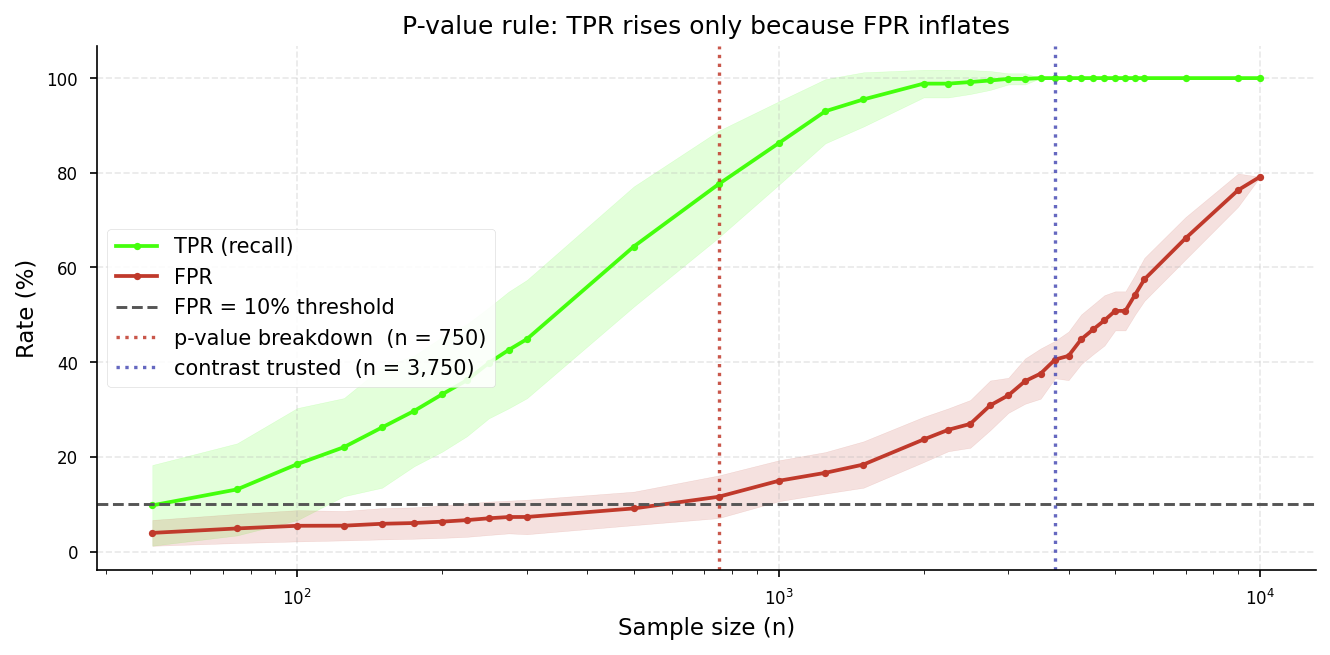

In [9]:
# FPR and TPR for p-value rule
fig, ax = plt.subplots(figsize=(9, 4.5))
x = cls_p["n_students"]

ps.band(ax, x, 100*cls_p["mean_tpr"], 100*cls_p["sd_tpr"], ps.C["pval"], label="TPR (recall)")
ps.band(ax, x, 100*cls_p["mean_fpr"], 100*cls_p["sd_fpr"], ps.C["star3"], label="FPR")

ax.axhline(100 * FPR_THRESHOLD, color=ps.C["neutral"], linestyle="--",
           linewidth=1.4, label=f"FPR = {FPR_THRESHOLD:.0%} threshold")
ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Rate (%)")
ax.set_title("P-value rule: TPR rises only because FPR inflates")
ax.legend(loc="center left")
plt.tight_layout()
ps.save(fig, figures_dir / "pval_classification.png")
plt.show()


## 6  DIF Contrast Method

Unlike the t-statistic, the contrast estimate Δ̂ = b̂ᵍ⁼¹ - b̂ᵍ⁼⁰ is not a function of n directly — it converges to the true δ as n → ∞.  
The plots below show that the Winsteps-style contrast achieves MAE ≤ 0.13 logits at n = 3 750, and FPR remains near 0% throughout.

**Caveat:** the contrast systematically underestimates δ for borderline items (δ near 0.43), keeping 3/12 injected DIF items below the threshold even at n = 10 000.


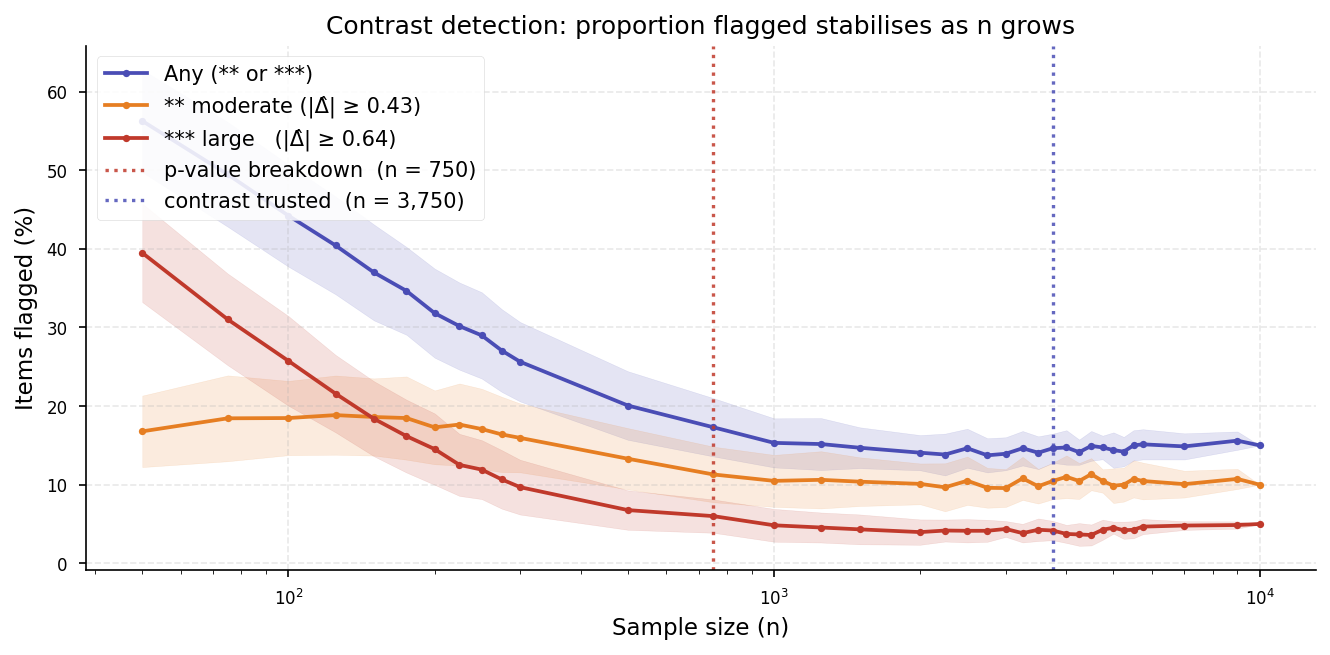

In [10]:
# Contrast proportion flagged
fig, ax = plt.subplots(figsize=(9, 4.5))
x = cf["n_students"]

ps.band(ax, x, 100*cf["mean_any"],   100*cf["sd_any"],   ps.C["contrast"],    label="Any (** or ***)")
ps.band(ax, x, 100*cf["mean_2star"], 100*cf["sd_2star"], ps.C["star1"],       label="** moderate (|Δ̂| ≥ 0.43)")
ps.band(ax, x, 100*cf["mean_3star"], 100*cf["sd_3star"], ps.C["star3"],       label="*** large   (|Δ̂| ≥ 0.64)")

ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Items flagged (%)")
ax.set_title("Contrast detection: proportion flagged stabilises as n grows")
ax.legend(loc="upper left")
plt.tight_layout()
ps.save(fig, figures_dir / "contrast_detection.png")
plt.show()


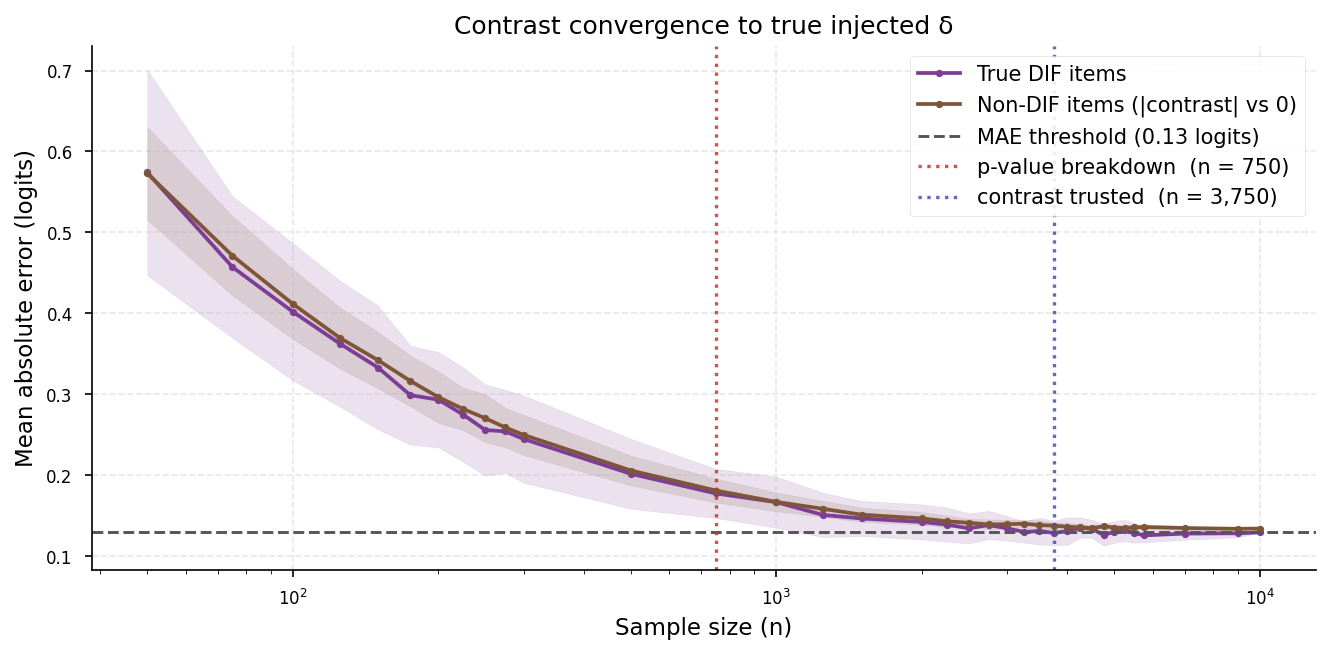

In [11]:
# MAE convergence
fig, ax = plt.subplots(figsize=(9, 4.5))
x = cc["n_students"]

ps.band(ax, x, cc["mean_dif"],   cc["sd_dif"],   ps.C["dif"],   label="True DIF items")
ps.band(ax, x, cc["mean_nodif"], cc["sd_nodif"], ps.C["nodif"], label="Non-DIF items (|contrast| vs 0)")

ax.axhline(MAE_THRESHOLD, color=ps.C["neutral"], linestyle="--",
           linewidth=1.4, label=f"MAE threshold ({MAE_THRESHOLD} logits)")
ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Mean absolute error (logits)")
ax.set_title("Contrast convergence to true injected δ")
ax.legend(loc="upper right")
plt.tight_layout()
ps.save(fig, figures_dir / "mae_convergence.png")
plt.show()


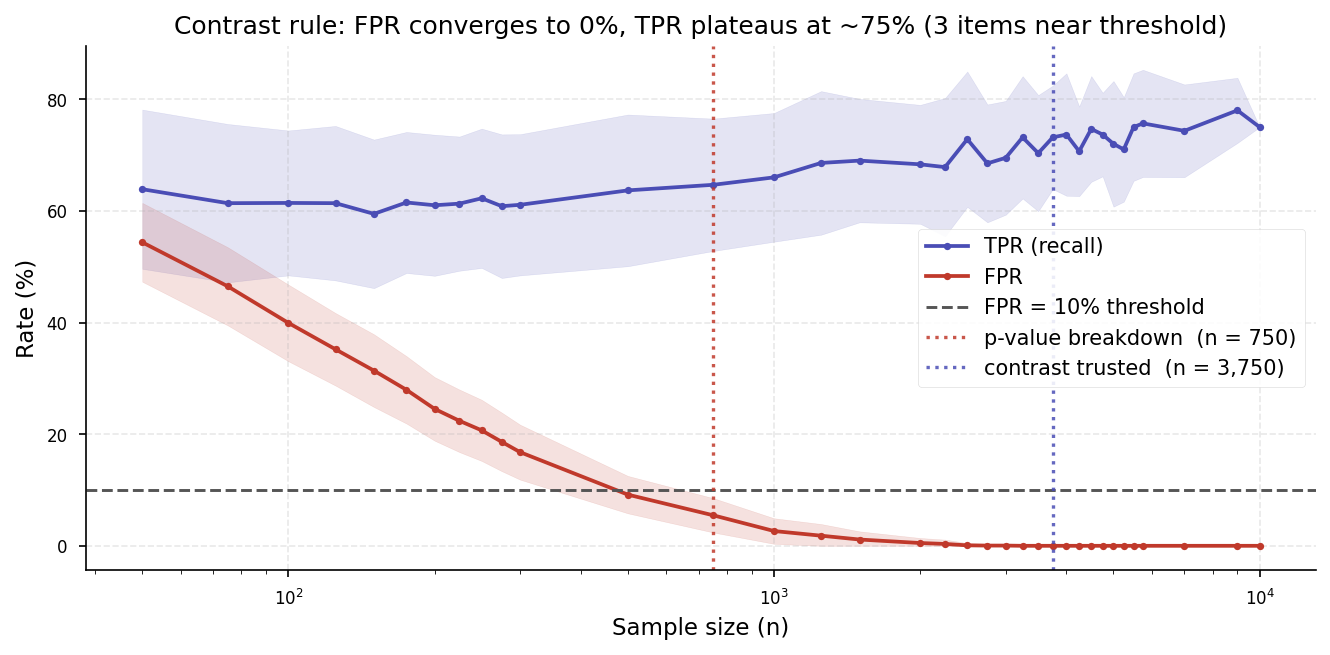

In [12]:
# FPR and TPR for contrast rule
fig, ax = plt.subplots(figsize=(9, 4.5))
x = cls_c["n_students"]

ps.band(ax, x, 100*cls_c["mean_tpr"], 100*cls_c["sd_tpr"], ps.C["contrast"], label="TPR (recall)")
ps.band(ax, x, 100*cls_c["mean_fpr"], 100*cls_c["sd_fpr"], ps.C["star3"],    label="FPR")

ax.axhline(100 * FPR_THRESHOLD, color=ps.C["neutral"], linestyle="--",
           linewidth=1.4, label=f"FPR = {FPR_THRESHOLD:.0%} threshold")
ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Rate (%)")
ax.set_title("Contrast rule: FPR converges to 0%, TPR plateaus at ~75% (3 items near threshold)")
ax.legend(loc="center right")
plt.tight_layout()
ps.save(fig, figures_dir / "contrast_classification.png")
plt.show()


## 7  Method Comparison

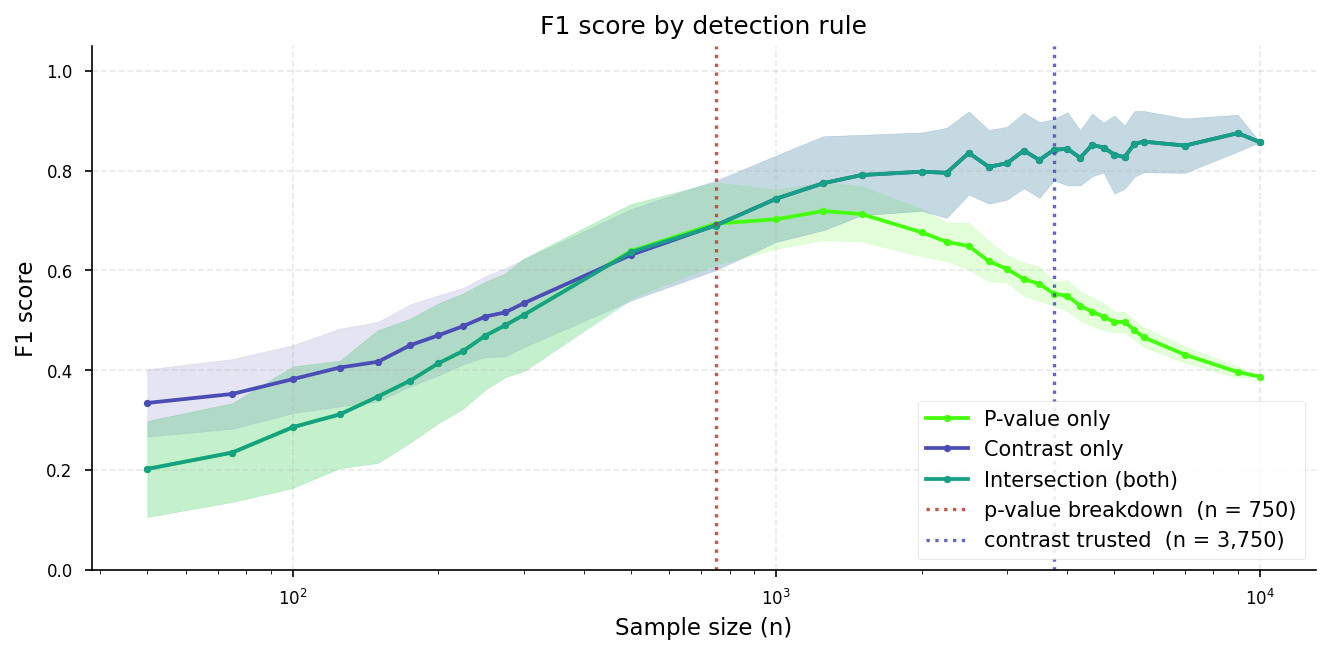

In [13]:
# F1 comparison
fig, ax = plt.subplots(figsize=(9, 4.5))

for summary, label, color in [
    (cls_p,    "P-value only",        ps.C["pval"]),
    (cls_c,    "Contrast only",       ps.C["contrast"]),
    (cls_both, "Intersection (both)", ps.C["intersection"]),
]:
    ps.band(ax, summary["n_students"], summary["mean_f1"], summary["sd_f1"],
            color=color, label=label)

ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)
ax.set_title("F1 score by detection rule")
ax.legend(loc="lower right")
plt.tight_layout()
ps.save(fig, figures_dir / "f1_comparison.png")
plt.show()


## 8  Supplementary

### 8.1  Contrast variance decay

Across-replication variance of Δ̂ falls as n increases.  
DIF items show higher variance at small n (wider estimation uncertainty for non-zero effects).


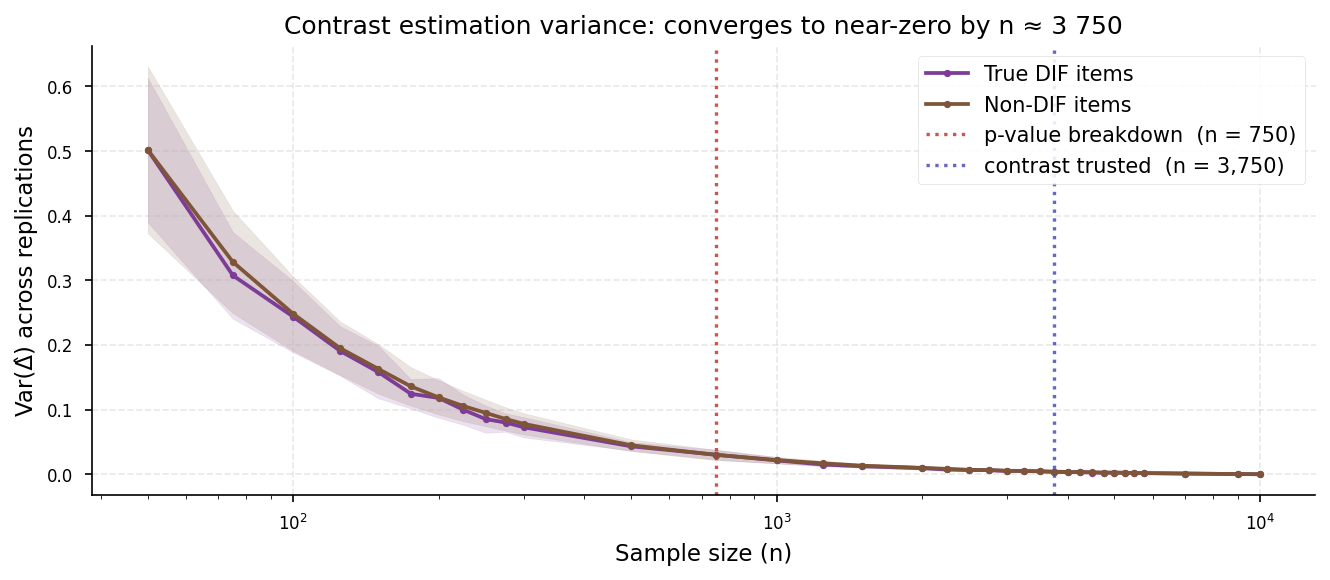

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

for dif_flag, label, color in [
    (True,  "True DIF items",  ps.C["dif"]),
    (False, "Non-DIF items",   ps.C["nodif"]),
]:
    sub = cv.loc[cv["dif_flag"] == dif_flag]
    ps.band(ax, sub["n_students"], sub["mean_var"], sub["sd_var"], color=color, label=label)

ps.add_thresholds(ax, n_break_p, n_trust_c)
ps.logx(ax, USE_LOG_X)
ax.set_xlabel("Sample size (n)")
ax.set_ylabel("Var(Δ̂) across replications")
ax.set_title("Contrast estimation variance: converges to near-zero by n ≈ 3 750")
ax.legend()
plt.tight_layout()
ps.save(fig, figures_dir / "contrast_variance.png")
plt.show()


### 8.2  Injected δ vs estimated |Δ̂| at n = n_max

Shows the systematic attenuation (underestimation) that keeps borderline items below the 0.43 threshold.  
The Winsteps-style residual correction shrinks estimates toward zero, especially for items with δ near the classification boundary.


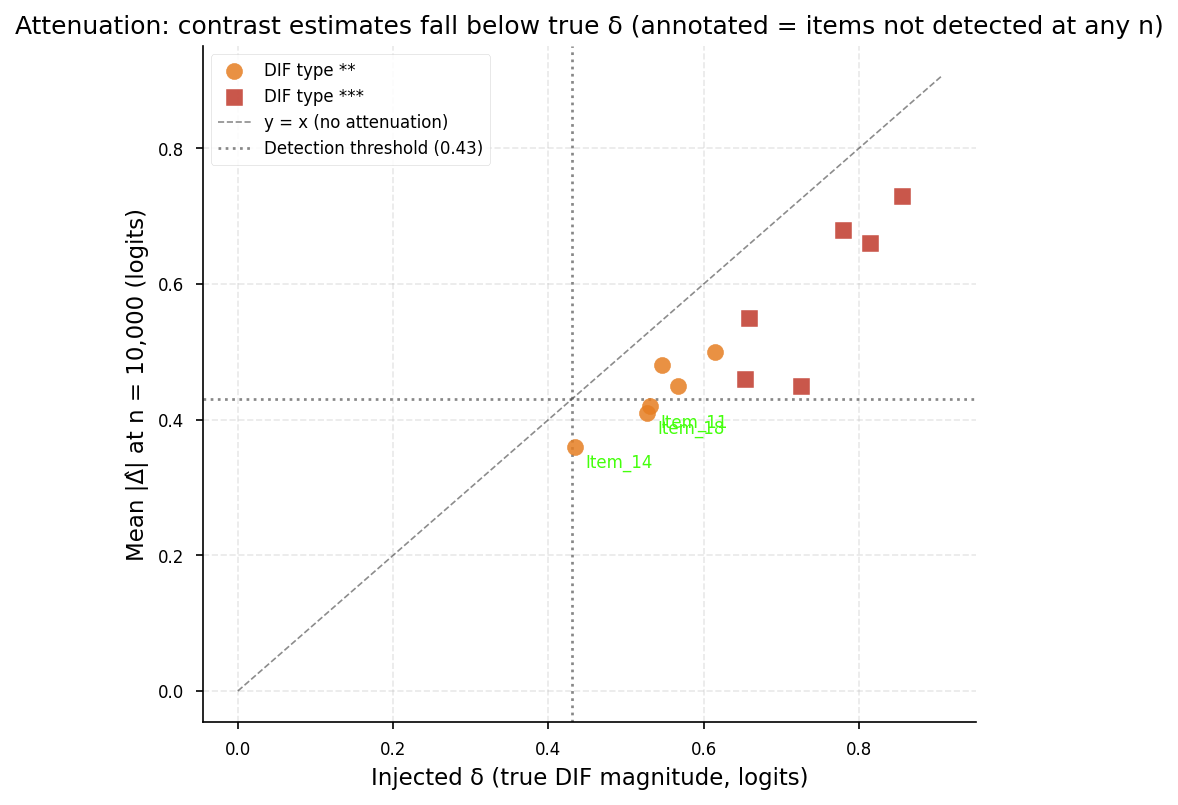

In [18]:
df_max = (
    item_df.loc[(item_df["n_students"] == max_n) & item_df["dif_flag"]]
    .groupby("item_id", as_index=False)
    .agg(
        mean_abs_contrast=("abs_contrast",   "mean"),
        delta_true        =("delta_group1",   "first"),
        dif_type          =("dif_type",       "first"),
        detection_rate    =("pred_contrast_detected", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(6, 5.5))

for dtype, color, marker in [
    ("**",  ps.C["star1"], "o"),
    ("***", ps.C["star3"], "s"),
]:
    sub = df_max.loc[df_max["dif_type"] == dtype]
    ax.scatter(sub["delta_true"], sub["mean_abs_contrast"],
               color=color, marker=marker, s=60, zorder=4,
               label=f"DIF type {dtype}", alpha=0.85)

# y = x reference and threshold lines
lim = max(df_max["delta_true"].max(), df_max["mean_abs_contrast"].max()) + 0.05
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.45, label="y = x (no attenuation)")
ax.axhline(CONTRAST_THRESHOLD, color=ps.C["neutral"], linestyle=":", linewidth=1.3, alpha=0.7,
           label=f"Detection threshold ({CONTRAST_THRESHOLD})")
ax.axvline(CONTRAST_THRESHOLD, color=ps.C["neutral"], linestyle=":", linewidth=1.3, alpha=0.7)

# Annotate undetected items (detection_rate == 0)
for _, row in df_max.loc[df_max["detection_rate"] == 0].iterrows():
    ax.annotate(row["item_id"],
                xy=(row["delta_true"], row["mean_abs_contrast"]),
                xytext=(5, -10), textcoords="offset points",
                fontsize=8, color=ps.C["pval"])

ax.set_xlabel("Injected δ (true DIF magnitude, logits)")
ax.set_ylabel("Mean |Δ̂| at n = {:,} (logits)".format(max_n))
ax.set_title("Attenuation: contrast estimates fall below true δ (annotated = items not detected at any n)")
ax.legend(fontsize=8)
plt.tight_layout()
ps.save(fig, figures_dir / "delta_vs_estimated_scatter.png")
plt.show()


### 8.3  Detection rate by DIF item at n = n_max

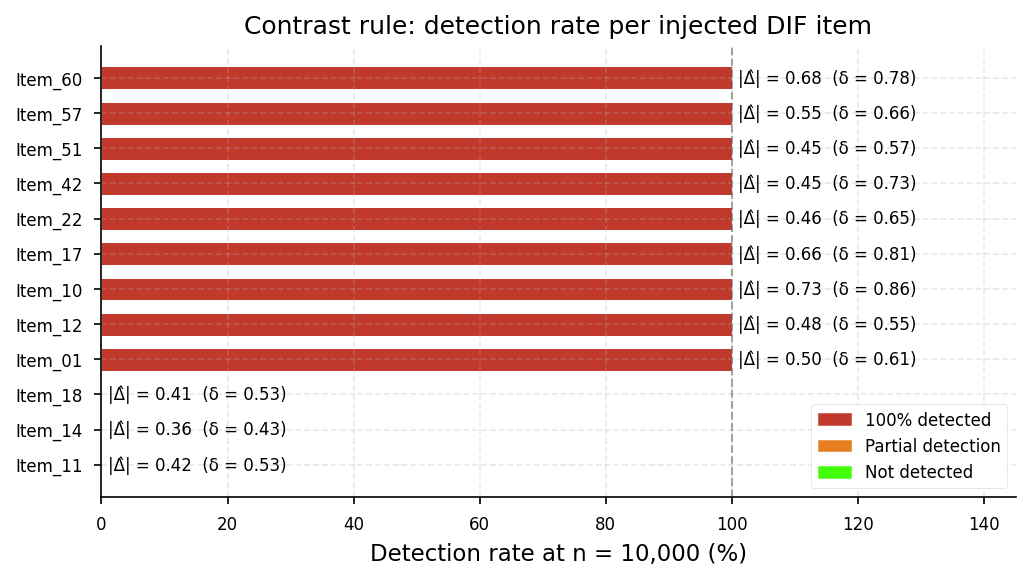

In [19]:
dif_det = (
    item_df.loc[(item_df["n_students"] == max_n) & item_df["dif_flag"]]
    .groupby("item_id", as_index=False)
    .agg(
        detection_rate =("pred_contrast_detected", "mean"),
        mean_contrast  =("abs_contrast",            "mean"),
        delta_true     =("delta_group1",            "first"),
        dif_type       =("dif_type",                "first"),
    )
    .sort_values("detection_rate")
)

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [ps.C["star3"] if r == 1.0 else (ps.C["star1"] if r > 0 else ps.C["pval"])
              for r in dif_det["detection_rate"]]

bars = ax.barh(dif_det["item_id"], dif_det["detection_rate"] * 100,
               color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65)

# Add mean |contrast| as text
for i, (_, row) in enumerate(dif_det.iterrows()):
    ax.text(row["detection_rate"]*100 + 1, i,
            f"|Δ̂| = {row['mean_contrast']:.2f}  (δ = {row['delta_true']:.2f})",
            va="center", fontsize=8)

ax.axvline(100, color=ps.C["neutral"], linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Detection rate at n = {:,} (%)".format(max_n))
ax.set_xlim(0, 145)
ax.set_title("Contrast rule: detection rate per injected DIF item")
# Legend patch
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=ps.C["star3"], label="100% detected"),
    Patch(color=ps.C["star1"], label="Partial detection"),
    Patch(color=ps.C["pval"],  label="Not detected"),
], loc="lower right", fontsize=8)
plt.tight_layout()
ps.save(fig, figures_dir / "missed_items.png")
plt.show()


### 8.4  Notes on undetected items

The three items that reach 0% detection rate at n_max (Item_11, Item_14, Item_18) all have  
injected δ in the range [0.43, 0.53] — straddling the Winsteps moderate threshold.  
The Winsteps-style residual correction consistently underestimates these contrasts (mean |$\hat{\Delta}$ $\approx$ 0.36–0.42),  
placing all replications below the 0.43 decision boundary.